# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

#### Problem 2 Written Answer: 

For this use case, an area plot is useful when we want to emphasize the total nutrient load of nitrate and phosphate combines over time. Its advantageous how we can provide a strong visual and make the overall trend more apparent but this may also be misleading because the top layer can often obscure the bottom one. Area plots are good when you want to see the combined impact but are not as useful when you want to examine features individually. The two line graphs on the other hand make it easier to compare nitrate and phosphorous against one another and individually. To improve the graphs shown, I would use distinct colors, labels, and a clear legend. 


In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

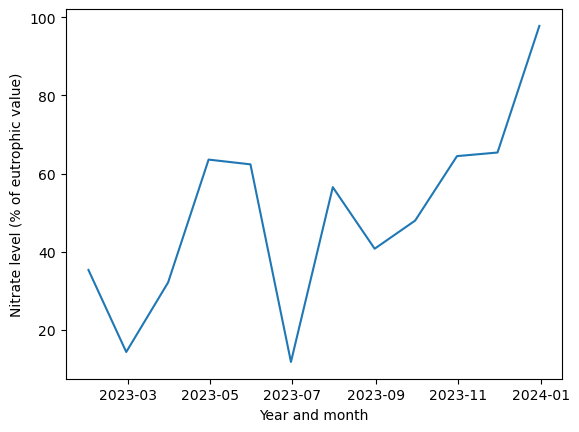

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

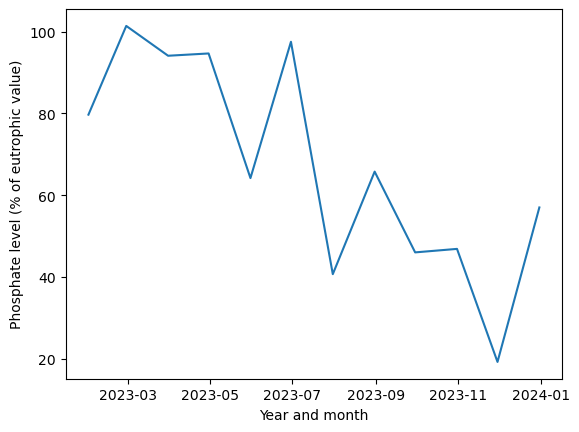

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

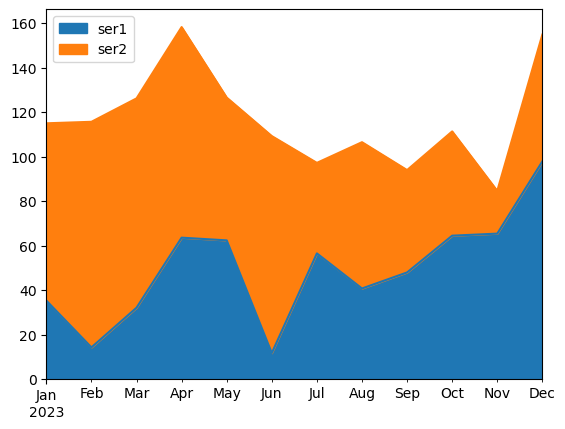

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Marketing Campaign Dataset - Exploratory Data Analysis
This notebook performs exploratory data analysis (EDA) on the Marketing Campaign Dataset. The goal is to explore correlations, visualize relationships, identify outliers, and evaluate data usability.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import kagglehub

# Download and load the dataset
marketing_dataset_path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
marketing_dataset_path_to_file = os.path.join(marketing_dataset_path, "marketing_campaign.csv")

marketing_dataset_raw = pd.read_csv(marketing_dataset_path_to_file, sep=';')

# Check for missing values and drop them
marketing_dataset_cleaned = marketing_dataset_raw.dropna()

marketing_dataset_cleaned.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## Correlation Analysis
Evaluate correlations between numerical variables.


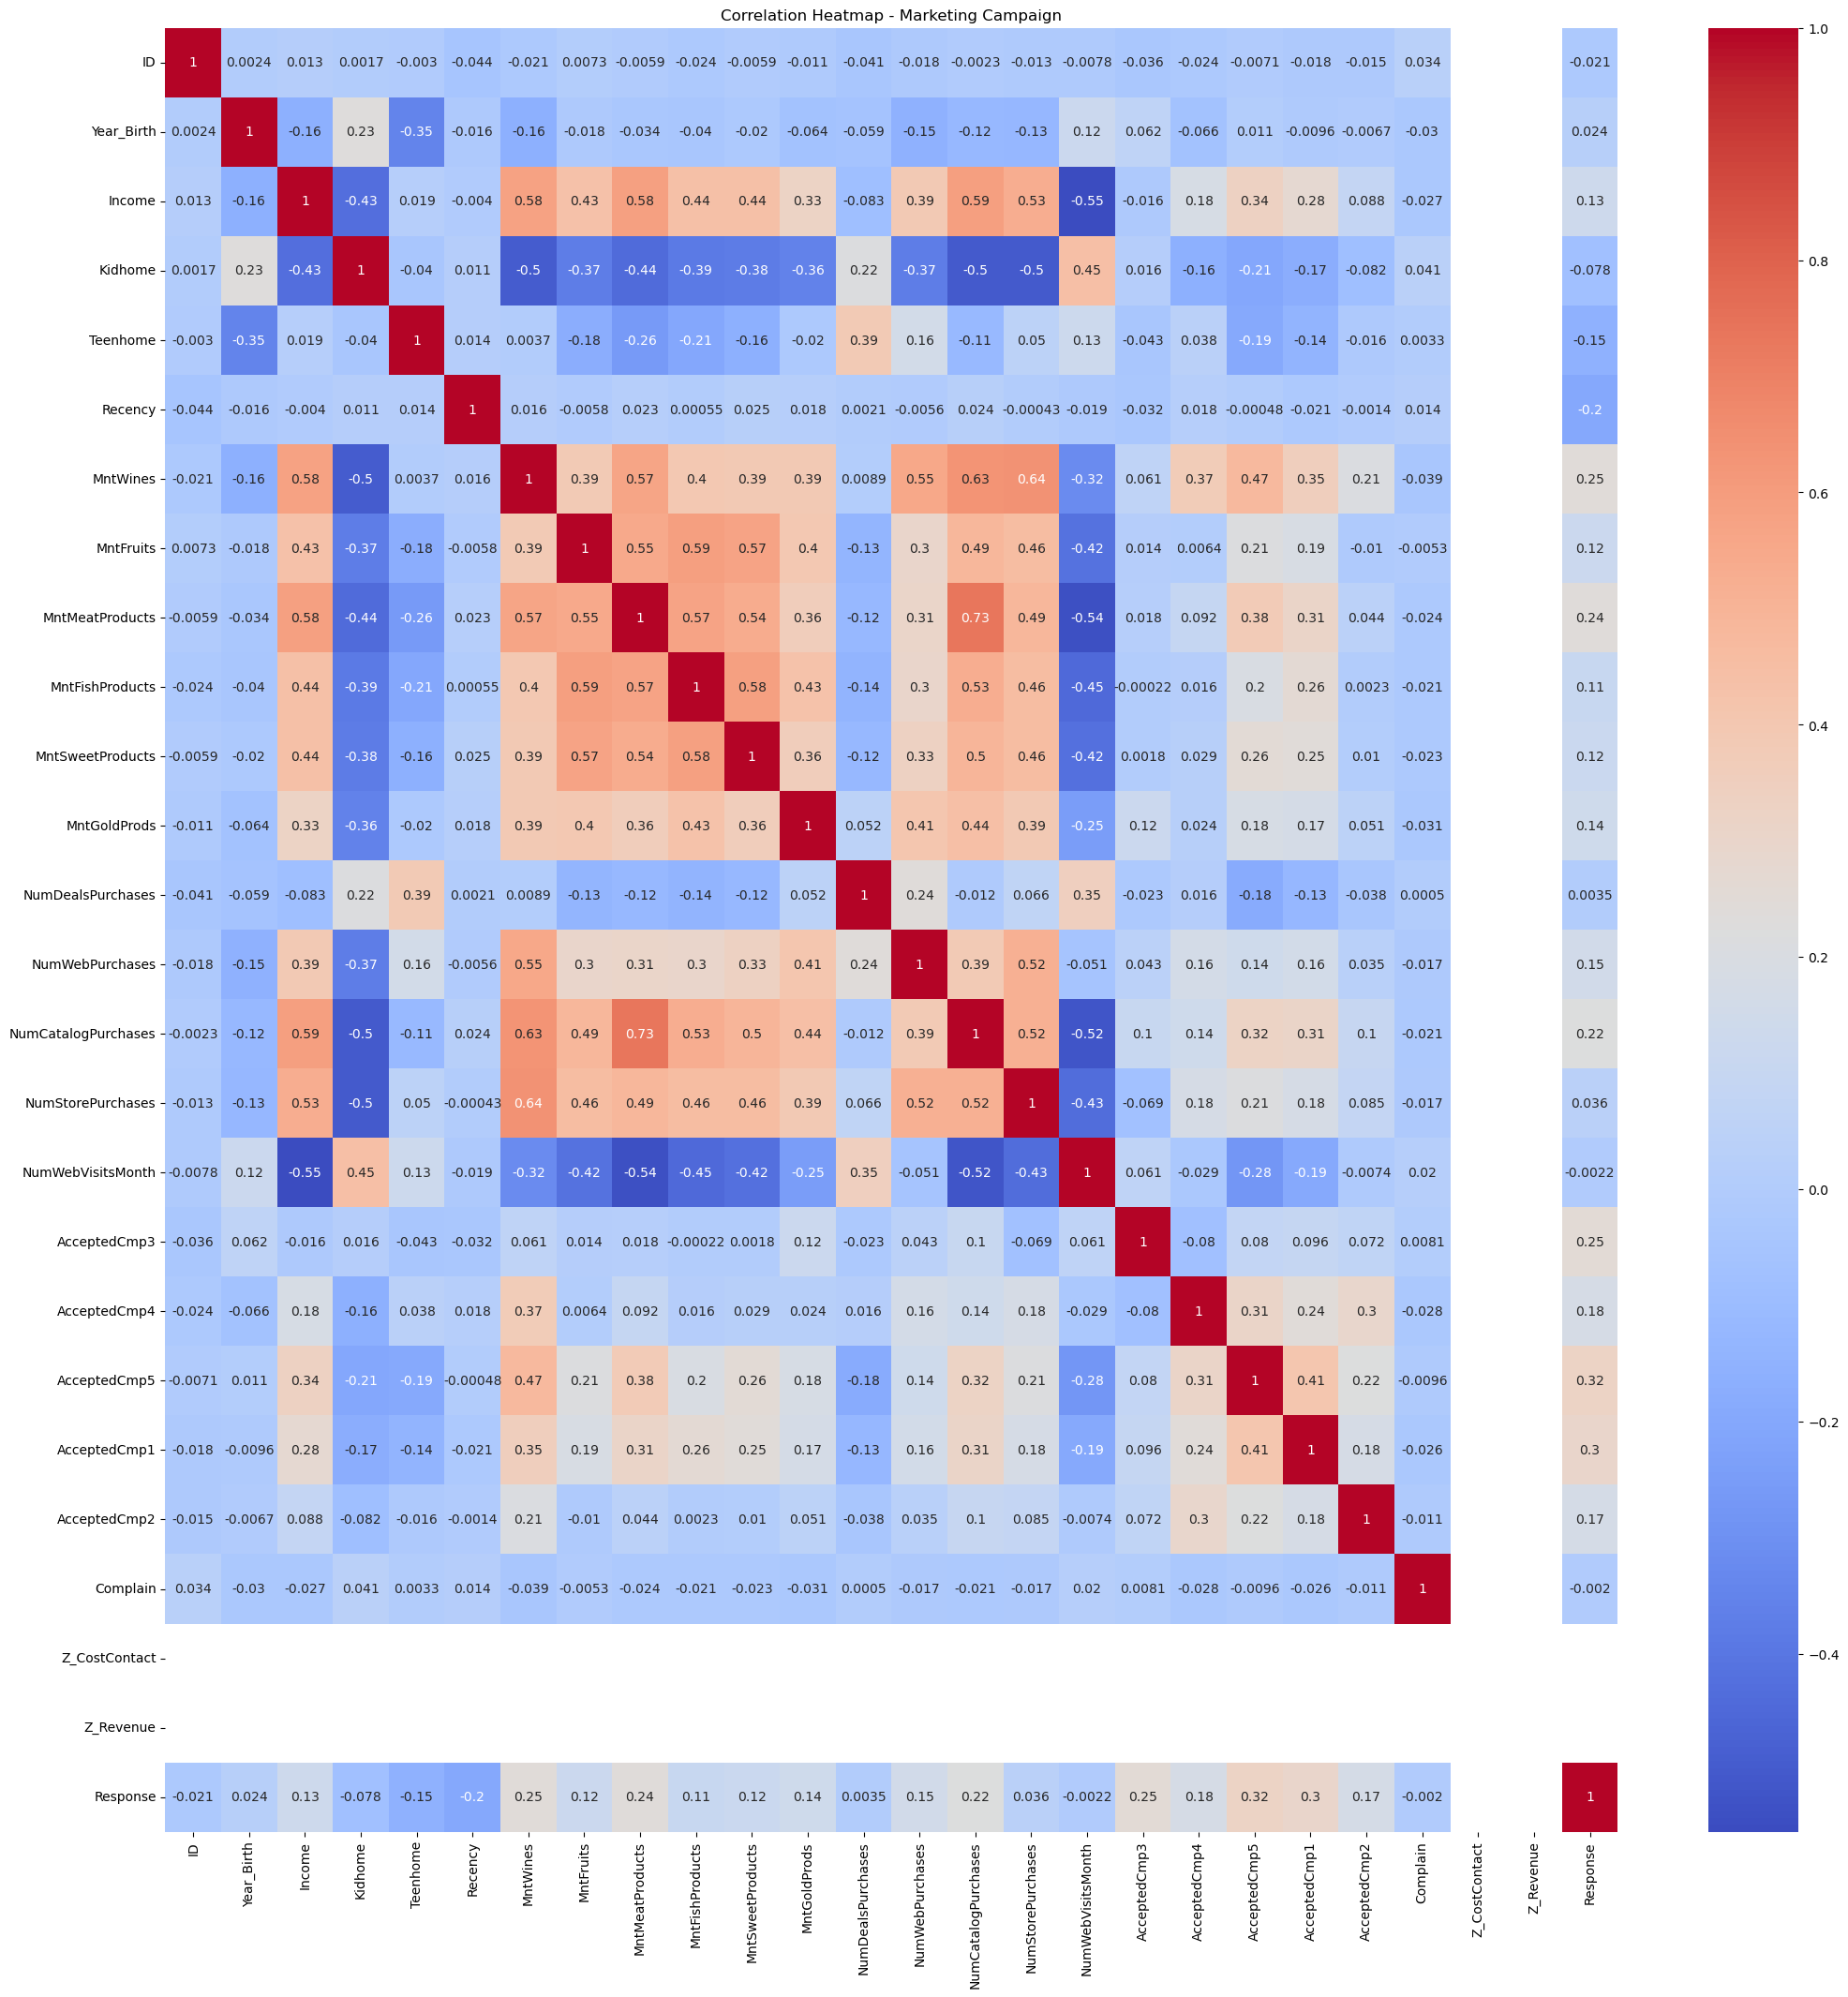

In [9]:
plt.figure(figsize=(25,25))
corr = marketing_dataset_cleaned.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Marketing Campaign")
plt.show()


## Scatterplots
Plot relationships for strongly correlated variable pairs.


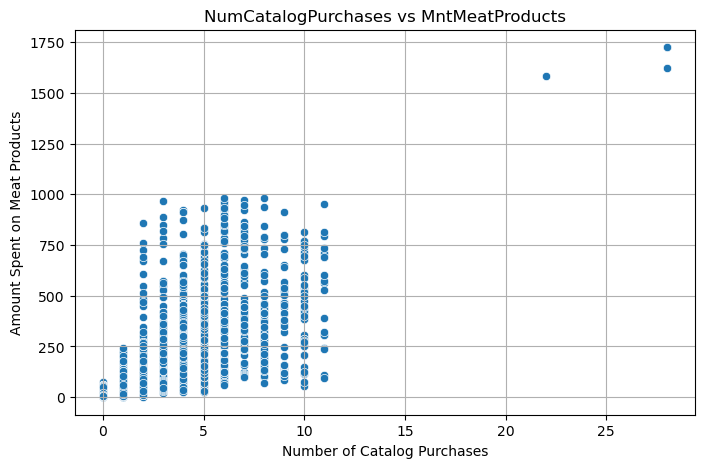

In [10]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=marketing_dataset_cleaned, x='NumCatalogPurchases', y='MntMeatProducts')
plt.title("NumCatalogPurchases vs MntMeatProducts")
plt.xlabel("Number of Catalog Purchases")
plt.ylabel("Amount Spent on Meat Products")
plt.grid(True)
plt.show()


## Pairplot
Visualize pairwise relationships.


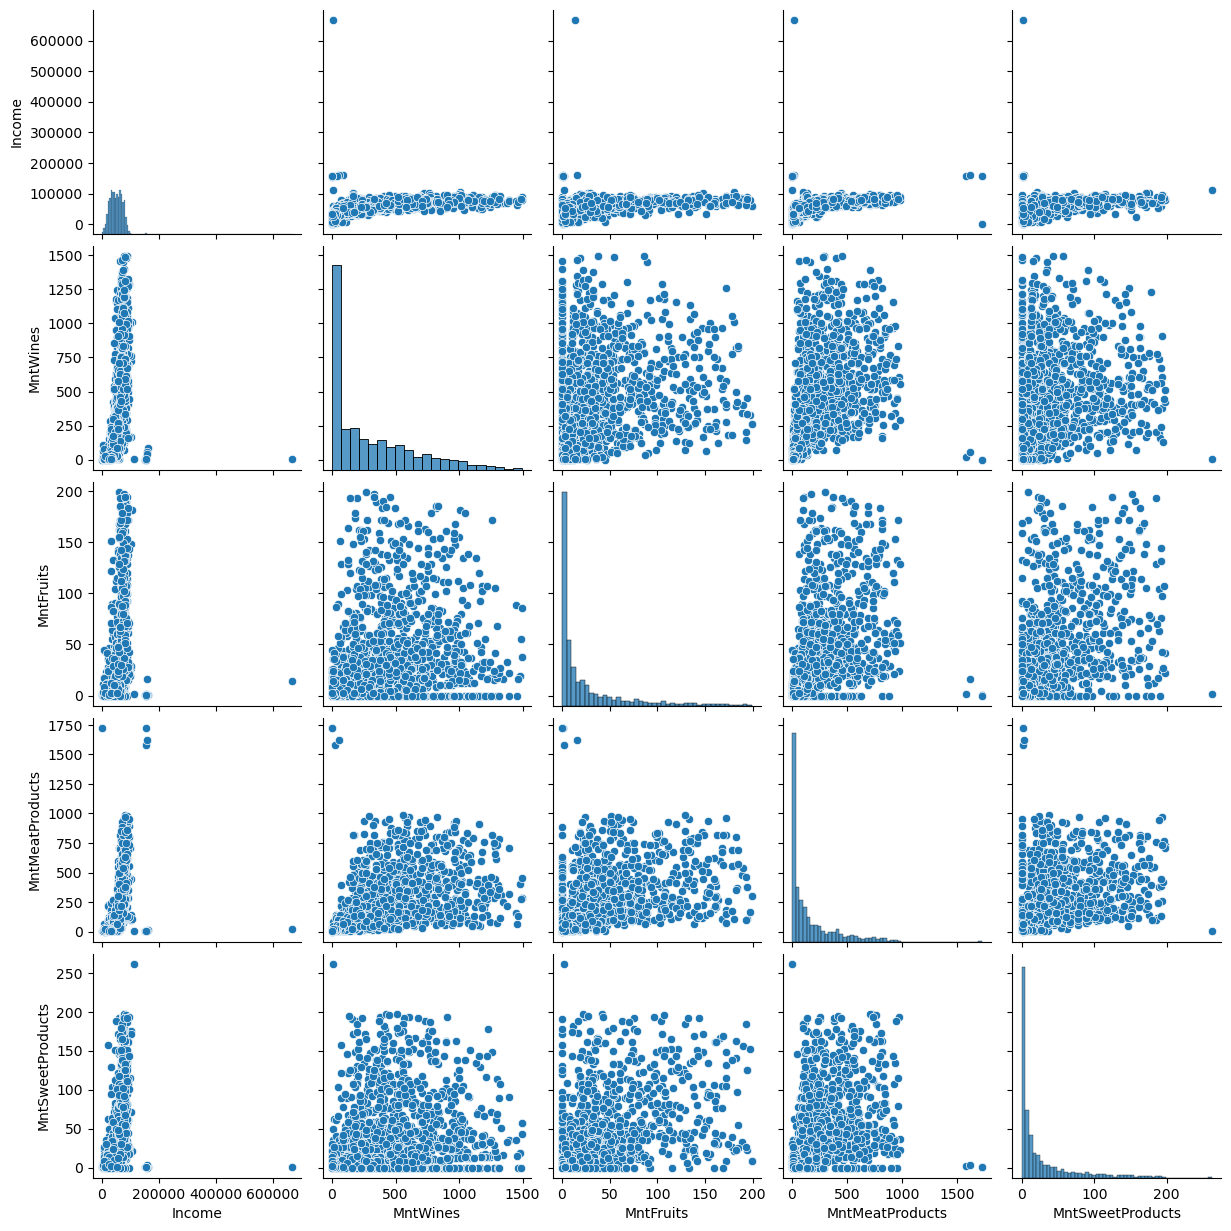

In [11]:
sns.pairplot(marketing_dataset_cleaned[['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntSweetProducts']])
plt.show()


## Line/Area Plot
Check for time-based patterns in 'Dt_Customer' (Date of Customer enrollment).


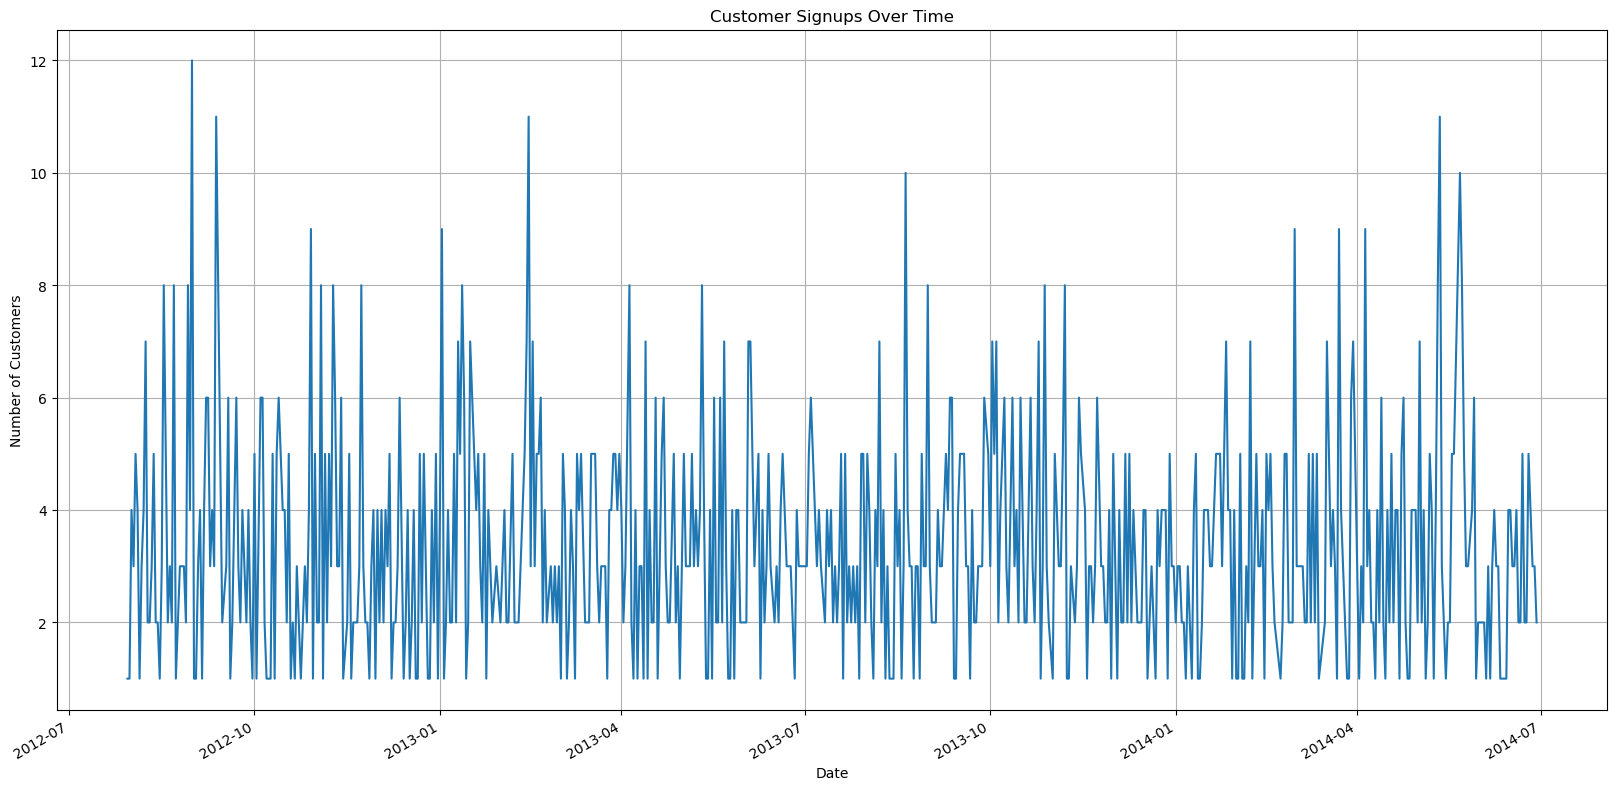

In [12]:
# Ensure the cleaned DataFrame is a proper copy
marketing_dataset_cleaned = marketing_dataset_raw.dropna().copy()

# Convert to datetime safely
marketing_dataset_cleaned['Dt_Customer'] = pd.to_datetime(marketing_dataset_cleaned['Dt_Customer'])

# Number of customers over time
customer_counts = marketing_dataset_cleaned.groupby('Dt_Customer').size()

plt.figure(figsize=(20,10))
customer_counts.plot(kind='line')
plt.title("Customer Signups Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

plt.show()


## Conclusions - Marketing Dataset

Outliers: Some extreme outliers in Income (above 600,000) and high spending on MntMeatProducts and MntWines. These should be reviewed for data accuracy or special customer cases.

Correlations: Strong correlations exist between product categories:

MntWines, MntFruits, MntMeatProducts, and MntSweetProducts are moderately to highly correlated, suggesting customers who spend in one category tend to spend in others.

NumCatalogPurchases correlates with MntMeatProducts and MntWines, indicating catalog buyers are also big spenders on products.

Trends: The line plot of customer signups over time shows no clear seasonal trend, but regular fluctuations suggest periodic marketing pushes or customer activity spikes.

Confounding Variables: Household variables like Kidhome and Teenhome, along with customer age (Year_Birth) and tenure (Dt_Customer), likely influence both income and purchasing behavior.

Data Usability: After dropping missing values, the data is clean and suitable for clustering, segmentation, and predictive modeling. Strong patterns in purchase behavior across different product types make this dataset valuable for customer profiling.




## Customer Churn Dataset - Exploratory Data Analysis
This notebook explores the Customer Churn dataset with correlation analysis, visualizations, and insights into churn behavior.


In [13]:
# Import
churn_dataset_path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")
churn_dataset_path_to_file = os.path.join(churn_dataset_path, "customer_churn_dataset-training-master.csv")

churn_dataset_raw = pd.read_csv(churn_dataset_path_to_file)

# Drop missing values
churn_dataset_cleaned = churn_dataset_raw.dropna()

# Remove leading and trailing spaces from column names
churn_dataset_cleaned.columns = churn_dataset_cleaned.columns.str.strip()


churn_dataset_cleaned.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## Correlation Analysis

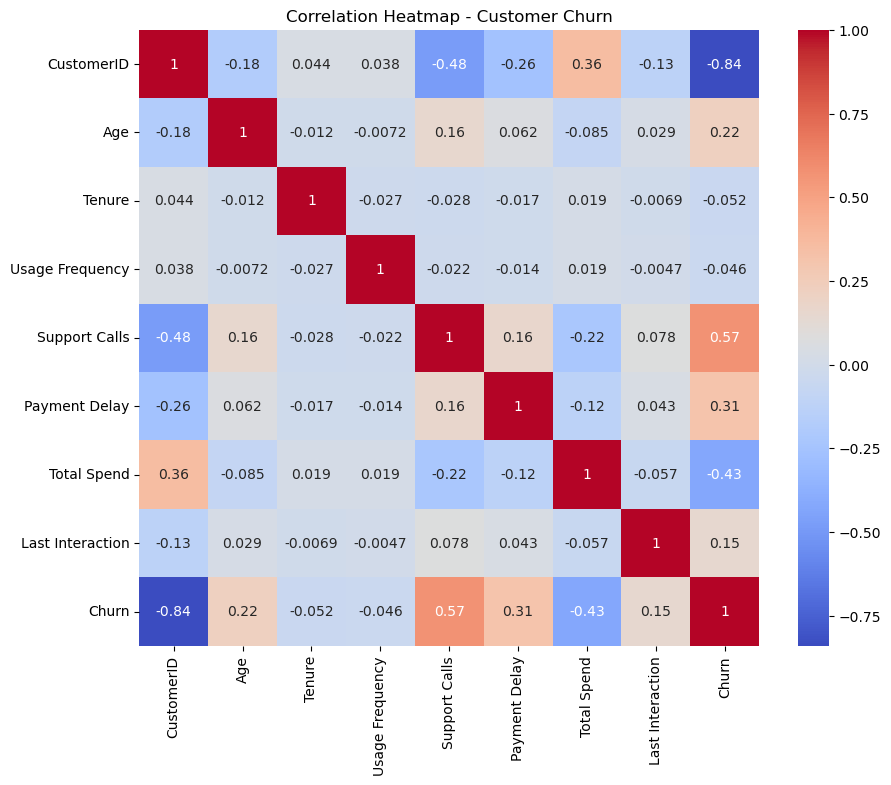

In [14]:
plt.figure(figsize=(10,8))
corr = churn_dataset_cleaned.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Customer Churn")
plt.show()


## Scatterplots

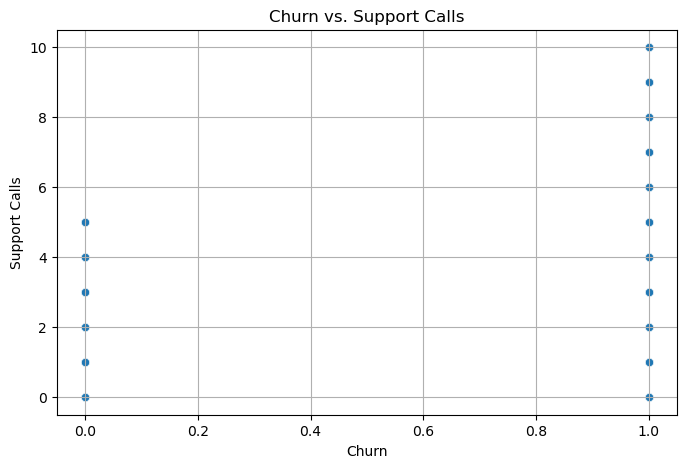

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=churn_dataset_cleaned, x='Churn', y='Support Calls')
plt.title('Churn vs. Support Calls')
plt.grid(True)
plt.show()


## Pairplot

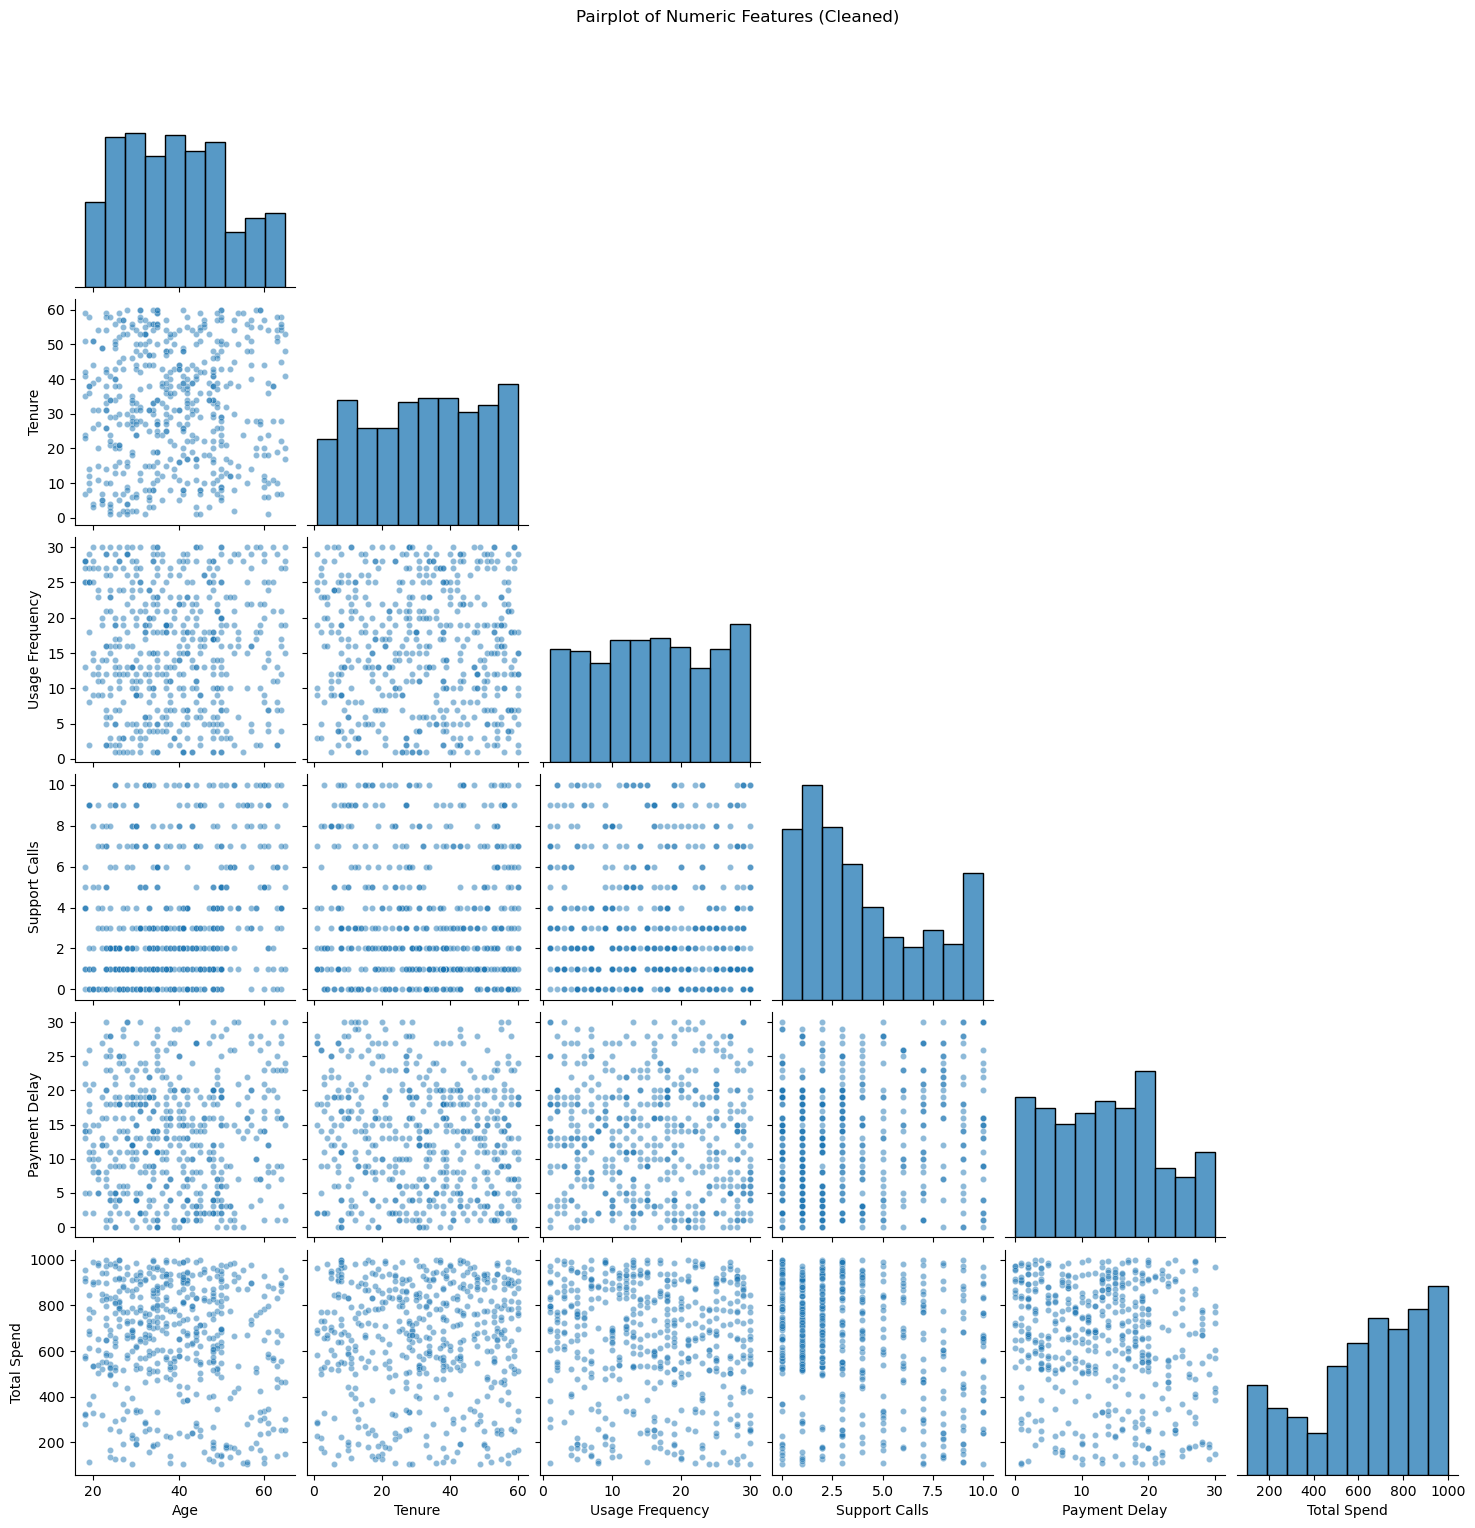

In [16]:

sampled_data = churn_dataset_cleaned.sample(n=500, random_state=42) if len(churn_dataset_cleaned) > 500 else churn_dataset_cleaned

sns.pairplot(
    sampled_data[['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend']],
    corner=True,                 
    diag_kind="hist",           
    plot_kws={'alpha': 0.5, 's': 20}  
)
plt.suptitle('Pairplot of Numeric Features (Cleaned)', y=1.02)
plt.show()


##  Line/Area Plot
Check trends of churn over tenure.


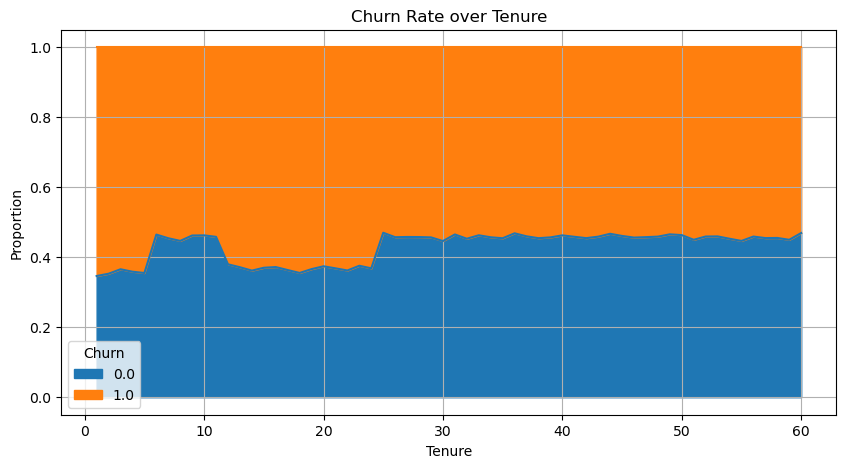

In [17]:
tenure_churn = churn_dataset_cleaned.groupby('Tenure')['Churn'].value_counts(normalize=True).unstack()

tenure_churn.plot(kind='area', stacked=True, figsize=(10,5))
plt.title("Churn Rate over Tenure")
plt.xlabel("Tenure")
plt.ylabel("Proportion")
plt.grid(True)
plt.show()


## Conclusions - Customer Churn Dataset

Outliers: Outliers are present in Support Calls (many customers at 0 and 10) and in Payment Delay with unusually high values. Some customers also show unusually high Total Spend relative to others.

Correlations: Support Calls has a strong positive correlation with Churn (0.57), suggesting customers who contact support more often are more likely to churn. Payment Delay also correlates moderately with Churn (0.31). Total Spend is negatively correlated with Churn (-0.43), meaning higher spending customers are less likely to churn.

Trends: The area plot of churn over tenure shows that churn slightly decreases with higher tenure — customers who have been with the company longer are somewhat less likely to churn, but churn remains relatively stable over time.

Confounding Variables: Variables like Subscription Type, Contract Length, and Age may influence both churn and other metrics like support calls, tenure, and payment behavior. These variables are likely confounders.

Data Usability: After dropping missing values and cleaning column names, the dataset is clean and appropriate for further modeling and analysis, including churn prediction.


##  Predict Conversion in Digital Marketing Dataset - Exploratory Data Analysis
Explore conversion factors using correlation analysis, visualizations, and time trends.


In [18]:
predict_conversion_dataset_path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")
predict_conversion_dataset_path_to_file = os.path.join(predict_conversion_dataset_path, "digital_marketing_campaign_dataset.csv")

predict_conversion_dataset_raw = pd.read_csv(predict_conversion_dataset_path_to_file)

# Drop missing values (if any)
predict_conversion_dataset_cleaned = predict_conversion_dataset_raw.dropna()

predict_conversion_dataset_cleaned.head()


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


## Correlation Analysis

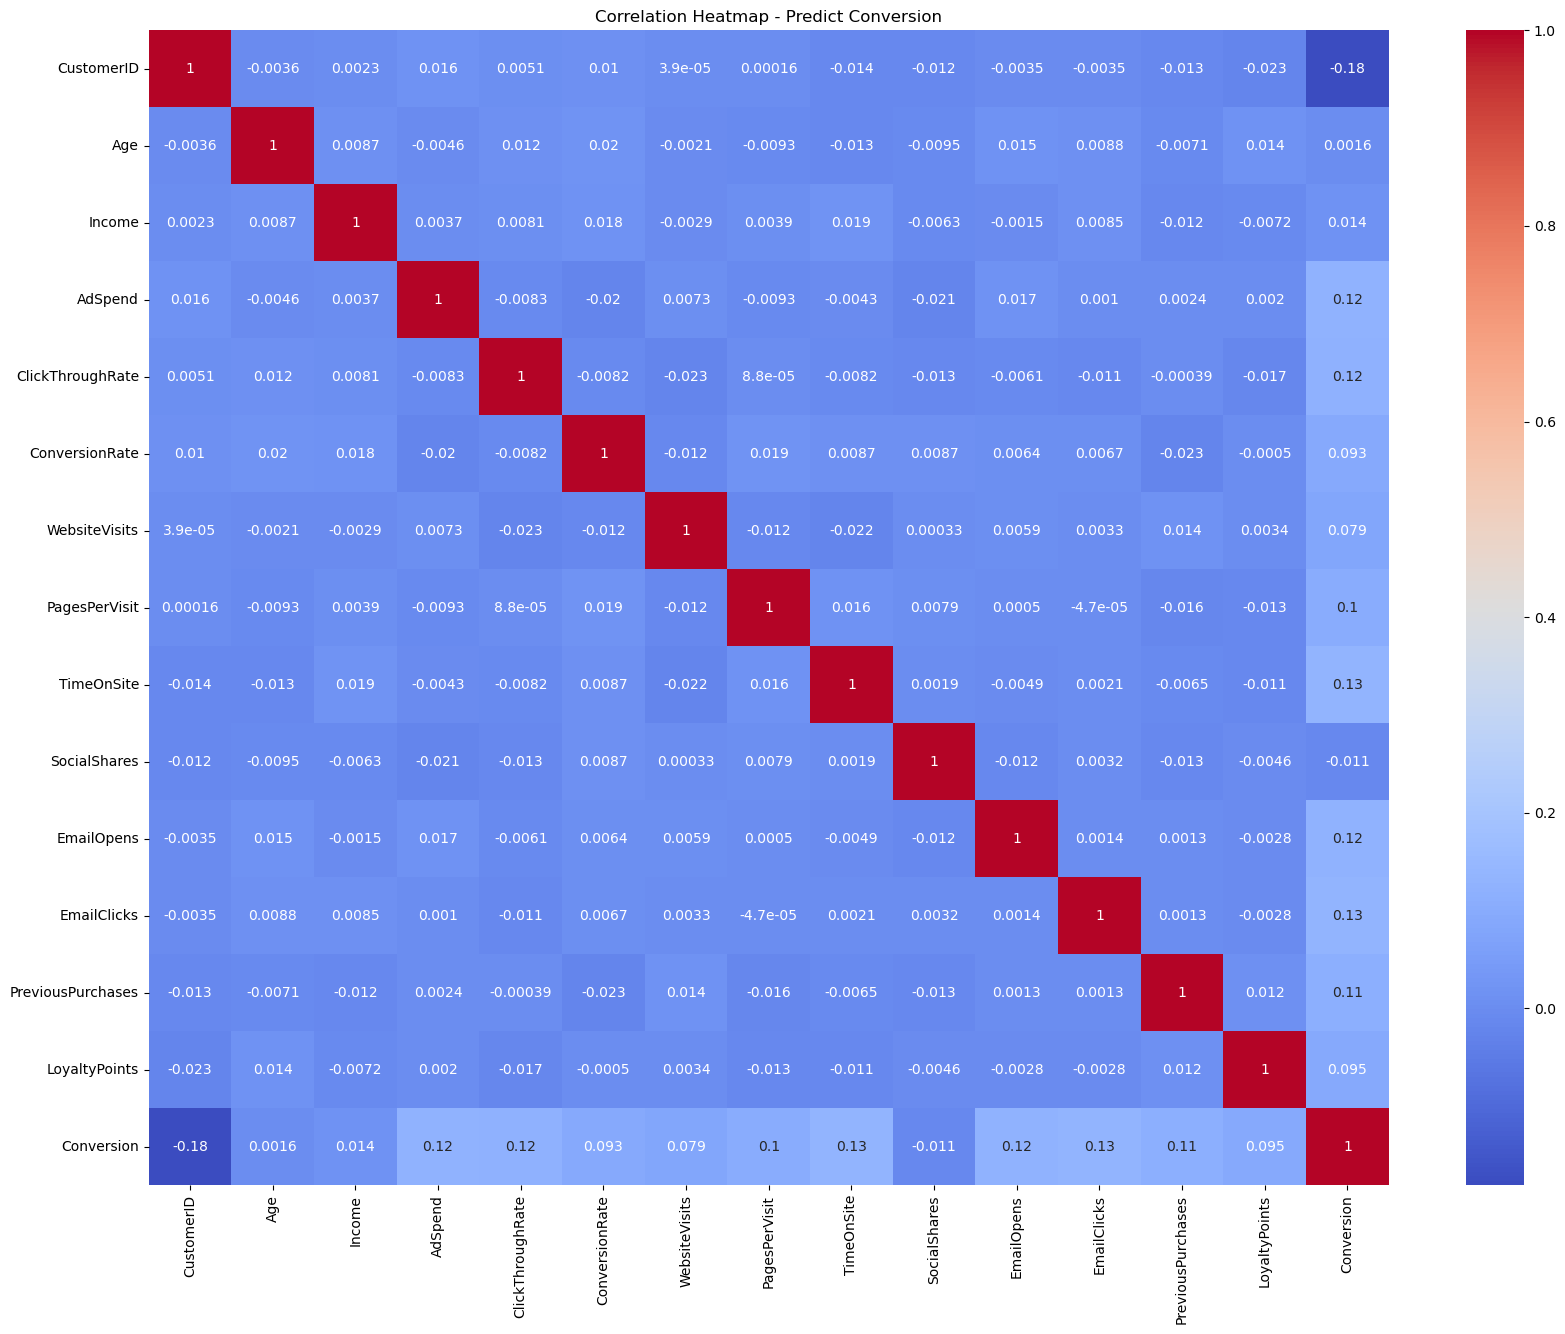

In [19]:
plt.figure(figsize=(20,15))
corr = predict_conversion_dataset_cleaned.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Predict Conversion")
plt.show()


## Scatterplots

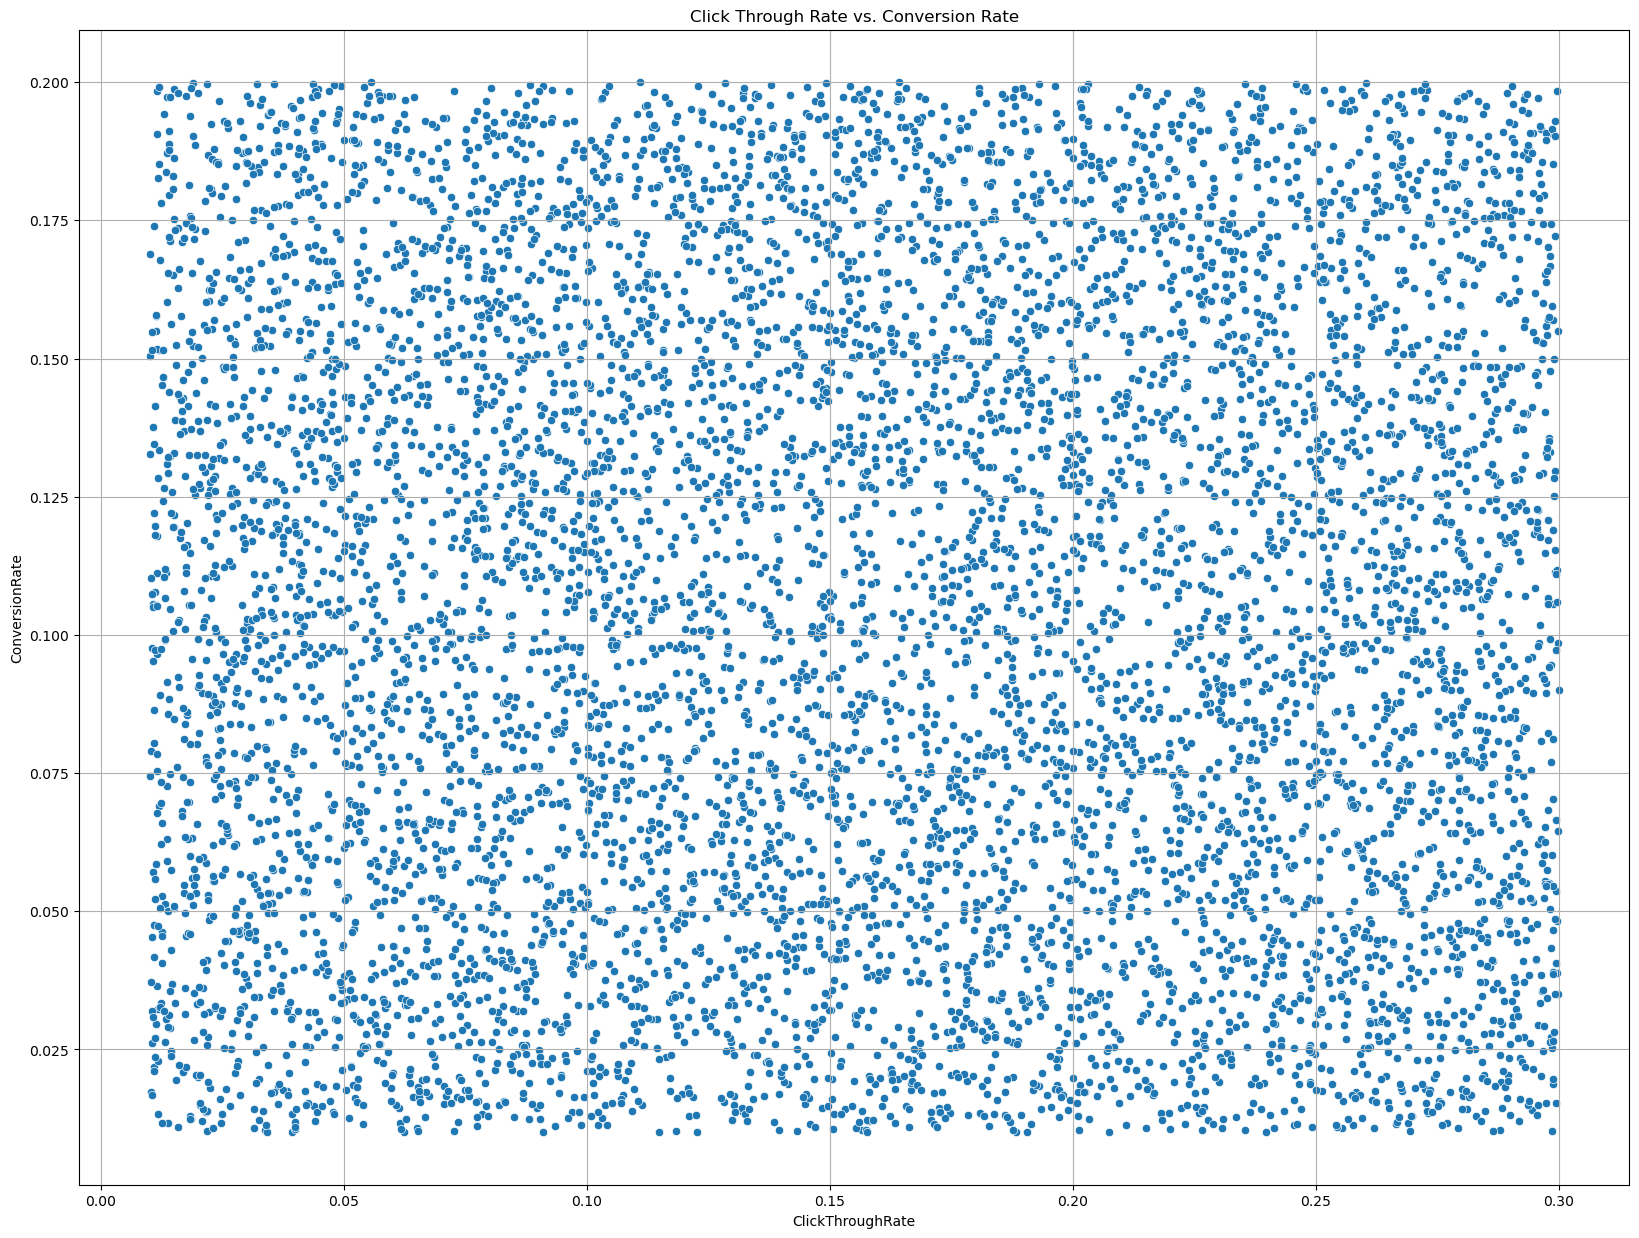

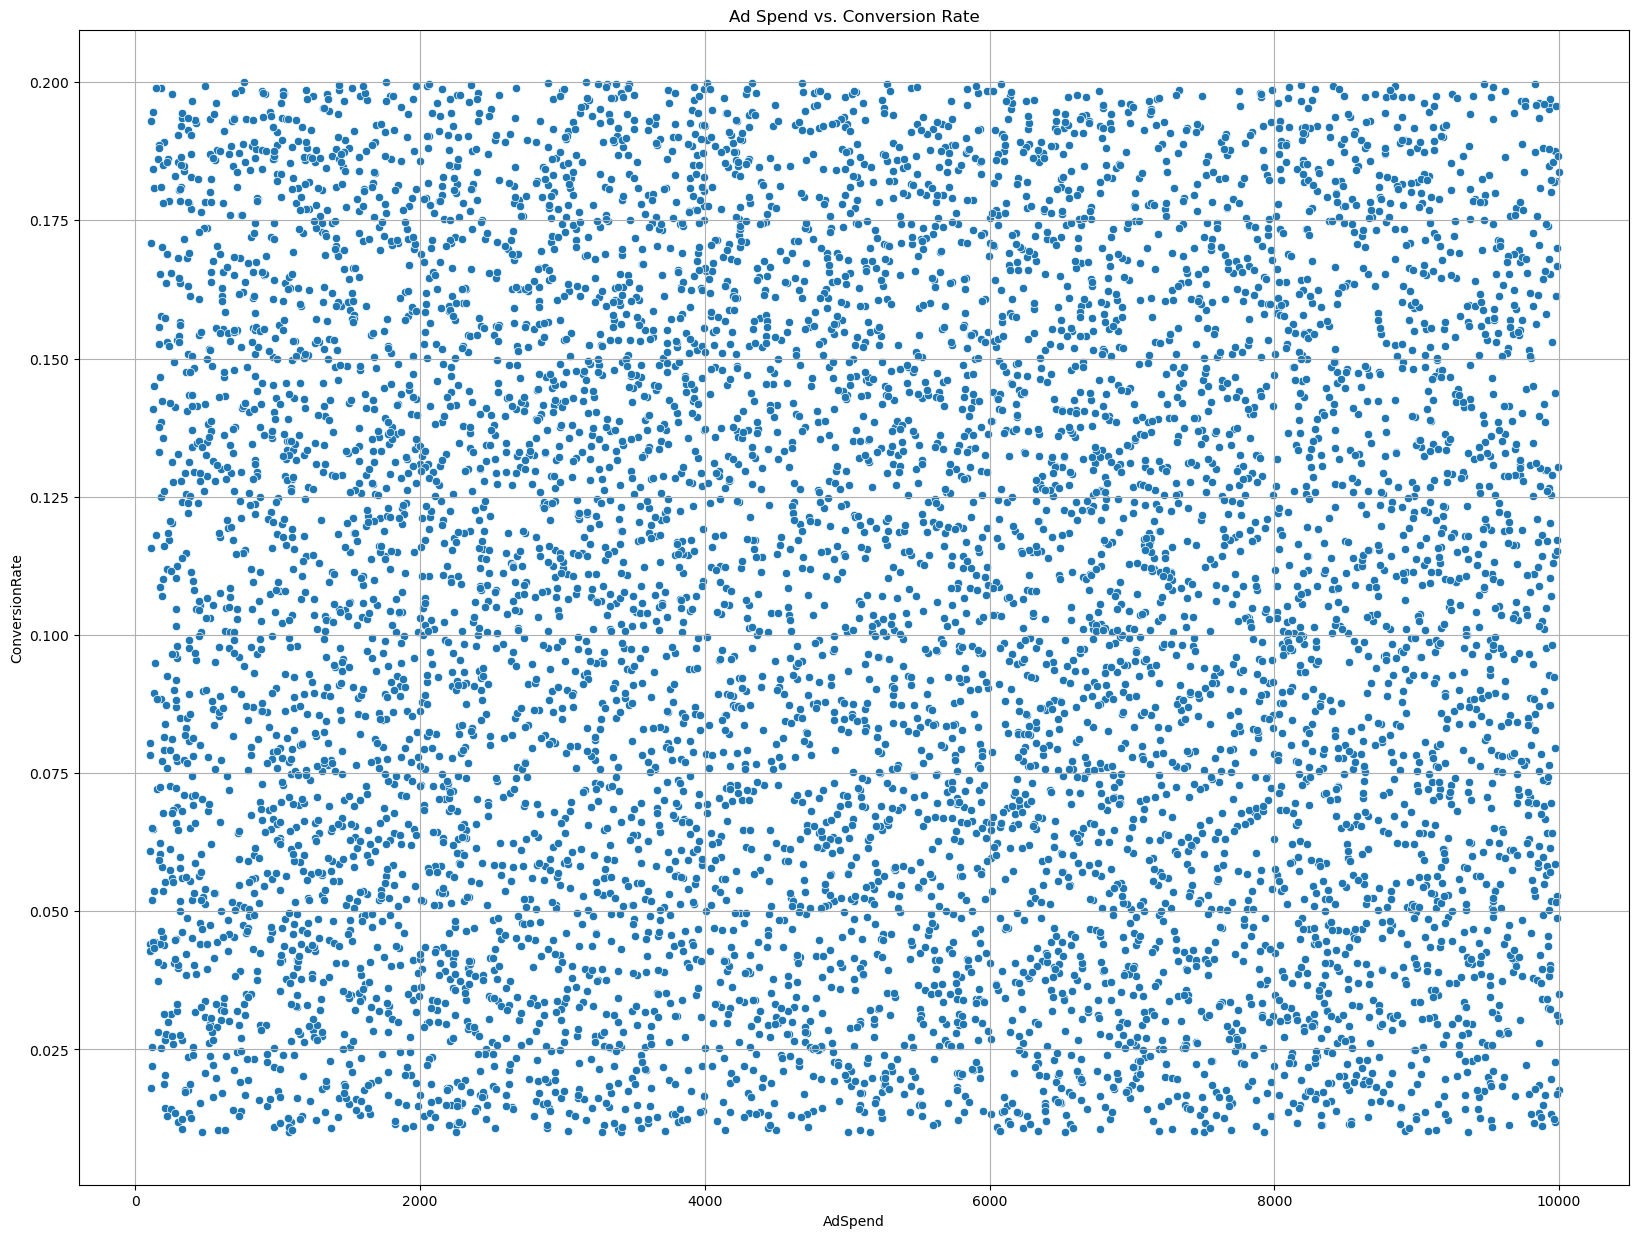

In [20]:
plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=predict_conversion_dataset_cleaned,
    x='ClickThroughRate',
    y='ConversionRate'
)
plt.title('Click Through Rate vs. Conversion Rate')
plt.grid(True)
plt.show()

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=predict_conversion_dataset_cleaned,
    x='AdSpend',
    y='ConversionRate'
)
plt.title('Ad Spend vs. Conversion Rate')
plt.grid(True)
plt.show()


## Pairplots

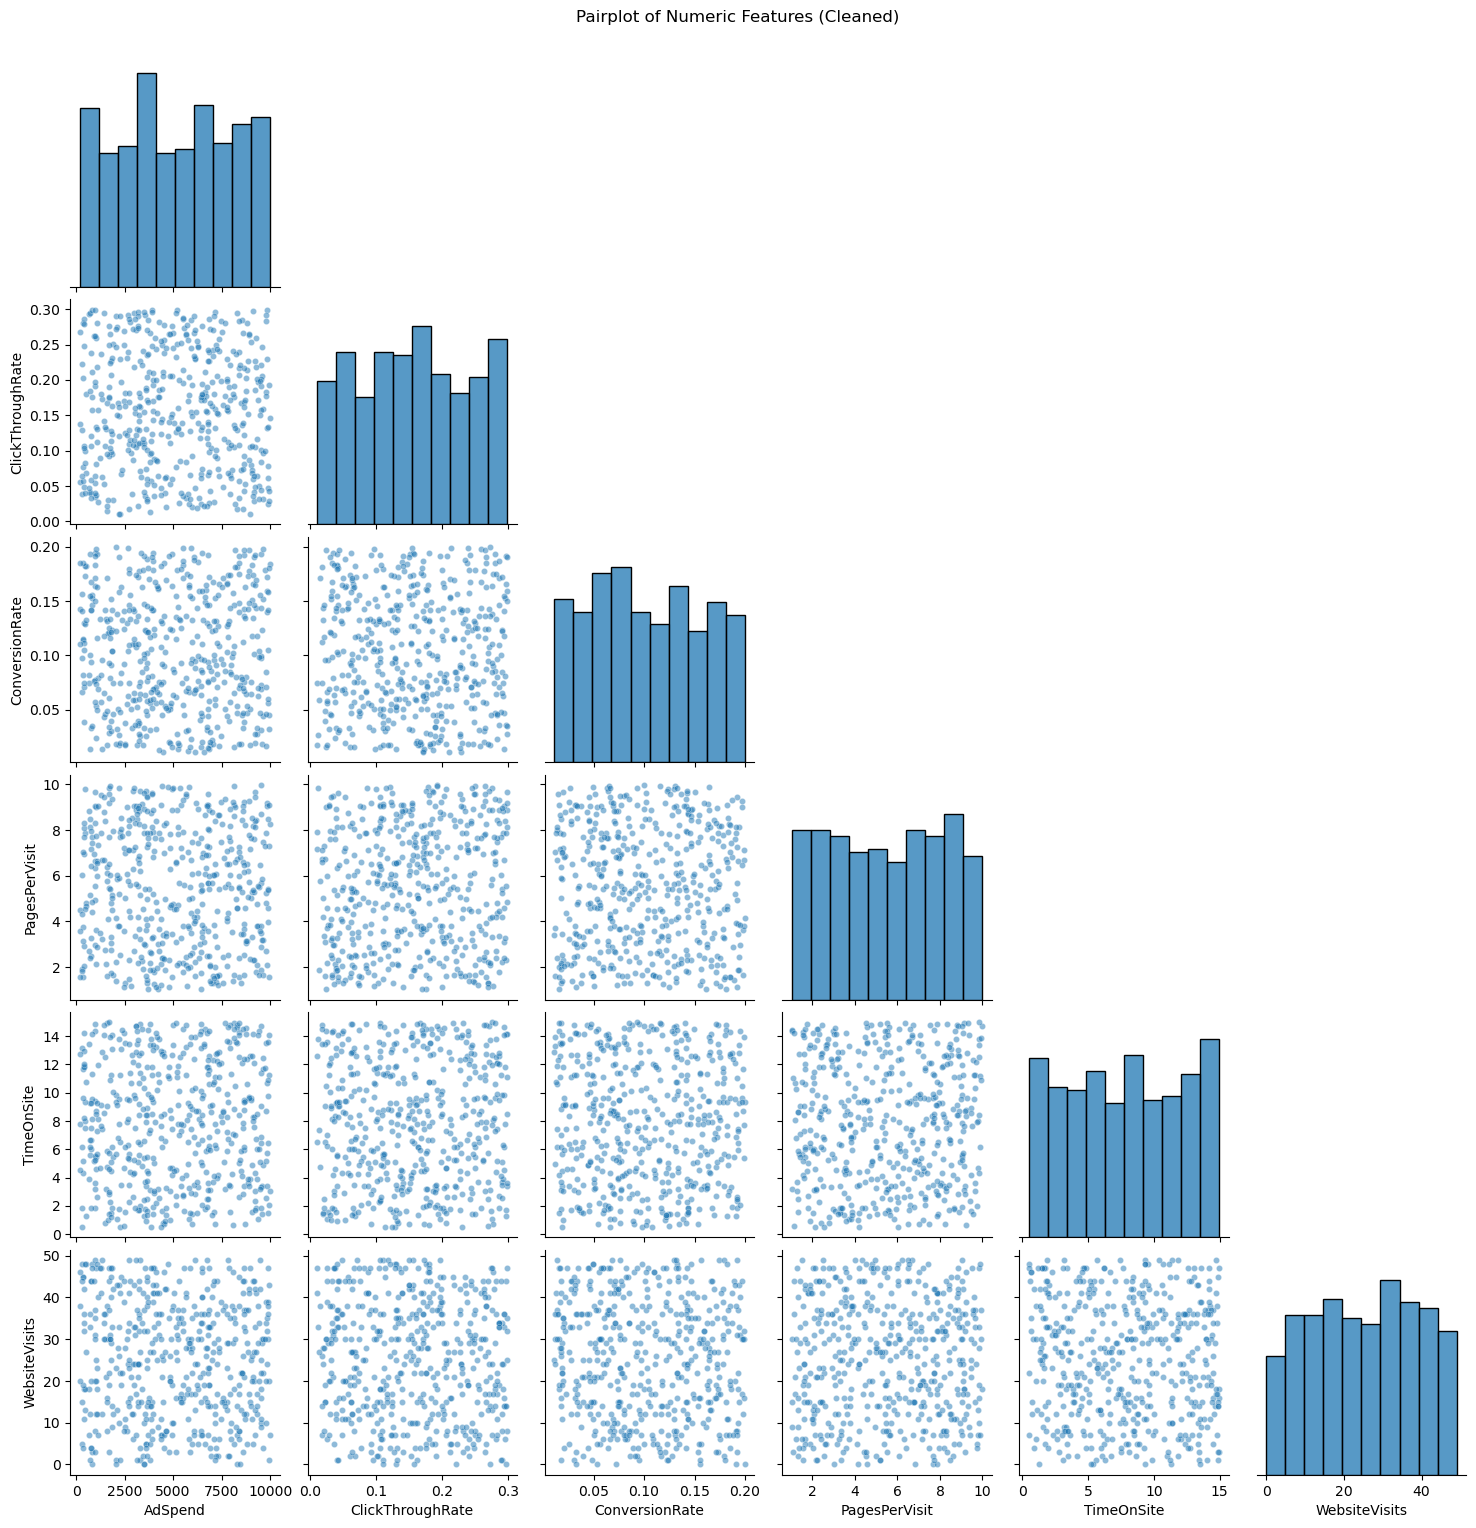

In [21]:
sampled_data = predict_conversion_dataset_cleaned.sample(n=500, random_state=42) if len(predict_conversion_dataset_cleaned) > 500 else predict_conversion_dataset_cleaned

sns.pairplot(
    sampled_data[['AdSpend', 'ClickThroughRate', 'ConversionRate', 'PagesPerVisit', 'TimeOnSite', 'WebsiteVisits']],
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 20}
)
plt.suptitle('Pairplot of Numeric Features (Cleaned)', y=1.02)
plt.show()


## Line /Area Plot 

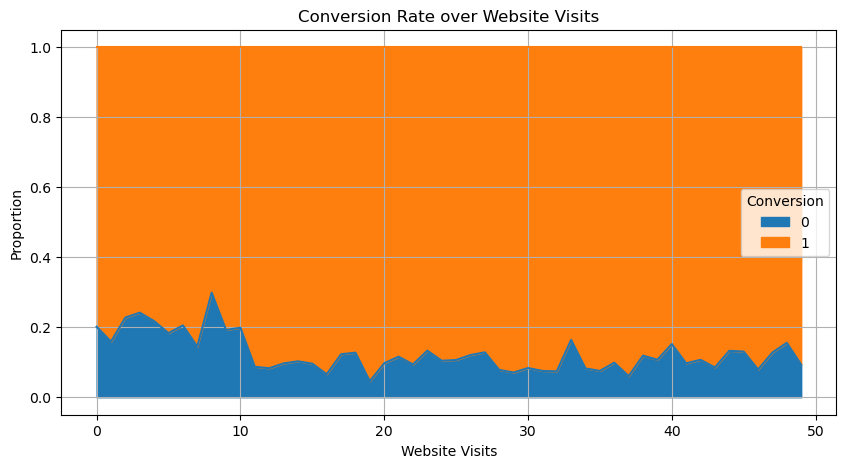

In [22]:
visits_conversion = predict_conversion_dataset_cleaned.groupby('WebsiteVisits')['Conversion'].value_counts(normalize=True).unstack()

visits_conversion.plot(kind='area', stacked=True, figsize=(10, 5))
plt.title("Conversion Rate over Website Visits")
plt.xlabel("Website Visits")
plt.ylabel("Proportion")
plt.grid(True)
plt.show()


## Conclusion 
Outliers: High AdSpend with low ConversionRate and spikes in PagesPerVisit and TimeOnSite.

Correlations: Very weak correlations overall. Slight positive relationships between ClickThroughRate, TimeOnSite, and ConversionRate. AdSpend has little to no correlation with conversion.

Trends: Conversion rates are stable across different WebsiteVisits counts with minor fluctuations.

Confounding Variables: Categorical factors like CampaignType, CampaignChannel, and AdvertisingPlatform likely drive conversion more than numeric features.

Data Usability: Clean and usable, but predictive power relies more on behavioral and categorical variables than numeric ones alone.



In [24]:
# Save cleaned Marketing Campaign dataset
marketing_dataset_cleaned.to_csv("marketing_campaign_cleaned.csv", index=False)

# Save cleaned Customer Churn dataset
churn_dataset_cleaned.to_csv("customer_churn_cleaned.csv", index=False)

# Save cleaned Predict Conversion dataset
predict_conversion_dataset_cleaned.to_csv("predict_conversion_cleaned.csv", index=False)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

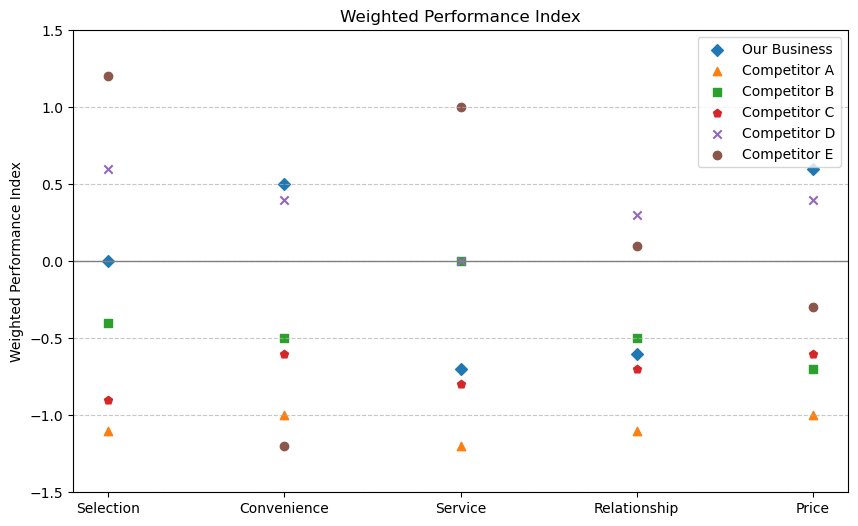

In [23]:
#figure 3.15 pg 87

import matplotlib.pyplot as plt
import numpy as np

categories = ["Selection", "Convenience", "Service", "Relationship", "Price"]
x = np.arange(len(categories))

our_business = [0.0, 0.5, -0.7, -0.6, 0.6]
competitor_a = [-1.1, -1.0, -1.2, -1.1, -1.0]
competitor_b = [-0.4, -0.5, 0.0, -0.5, -0.7]
competitor_c = [-0.9, -0.6, -0.8, -0.7, -0.6]
competitor_d = [0.6, 0.4, 0.0, 0.3, 0.4]
competitor_e = [1.2, -1.2, 1.0, 0.1, -0.3]

plt.figure(figsize=(10, 6))
plt.axhline(0, color='gray', linewidth=1)  

plt.scatter(x, our_business, label='Our Business', marker='D')
plt.scatter(x, competitor_a, label='Competitor A', marker='^')
plt.scatter(x, competitor_b, label='Competitor B', marker='s')
plt.scatter(x, competitor_c, label='Competitor C', marker='p')
plt.scatter(x, competitor_d, label='Competitor D', marker='x')
plt.scatter(x, competitor_e, label='Competitor E', marker='o')

plt.title("Weighted Performance Index")
plt.ylabel("Weighted Performance Index")
plt.xticks(x, categories)
plt.ylim(-1.5, 1.5)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

